# **LÓGICA FUZZY**

Na literatura o termo "lógica fuzzy"é usado de duas formas diferentes:

• teoria conjuntista a fim de manipular informações inexatas, nebulosas, por meio de
uma teoria de conjuntos fuzzy geral;

• lógica no sentido de "cálculo proposicional", de modo a estender a lógica
clássica.

*A lógica difusa tem por objetivo modelar modos de
raciocínio aproximados ao invés de precisos.*


• Na lógica difusa as proposições podem ter valores
intermediários entre "Verdadeiro" e "Falso". A veracidade
destas é uma função que pode assumir qualquer valor
entre 0 (absolutamente falso) e 1 (absolutamente
verdadeiro).

• As sentenças passam a ter um grau de pertinência.

**• Lógica Clássica**

o Predicados exigem definição exata
o Não existe resposta diferente de verdadeiro ou falso.
 é homem, é mortal, é par ...

**• Lógica Difusa**

o Predicados não possuem definição exata
o Respostas são relativas; Possuem um grau de
veracidade que variam entre “totalmente falso” e
“totalmente verdadeiro”:
é alto, está cansado, é jovem ...

**Exemplo de aplicação de Lógica Fuzzy em Python**

Fator custo/benefício (CB) na decisão de compra de um veículo baseada em três variáveis:
- P: preço de aquisição (baixo e alto)
- C: consumo de combustível (baixo e alto)
- CR: custo da revisão de 50.000 Km (baixo e alto)

Então:

**SE** (P é baixo) **OU** (C é baixo) **OU** (CR é baixo) **ENTÃO** CB é alto

**SE** (P é baixo) **E** (C é baixo) **E** (CR é baixo) **ENTÃO** CB é alto


Entretanto:

- O que é baixo?
- O que é alto?
- O que podemos considerar como consumo baixo?
- O que podemos considerar como preço de aquisição baixo?
- O que podemos considerar como custo de revisão baixo?

- Em termos de lógica booleana a resposta é limitada, pois:

 -7 pertence ao conjunto dos números inteiros (Z);

 mas:

 -7 não pertence ao conjunto dos números naturais (N)

- O pertencimento a um conjunto é limitado.

- Na Lógica Fuzzy, temos graus de pertinencia, e não apenas pertence ou não pertence. Ouseja, um elemento pode pertencer mais ou menos a um determinado conjunto.
- A lógica Fuzzy encontra aplicação frequente em problemas que requerem o uso de linguagem natural, onde a variabilidade de uma grandeza é expressa por variáveis linguísticas (gelado,frio,morno,quente), e um determinado procedimento deve ser adotado em função do grau de pertencimento da grandeza a uma variável linguística.

No sentido de criarmos um pequeno sistema fuzzy, determinaremos os limites possíveis para nossas variáveis nos seguintes termos:

a) Preço de aquisição: entre  R&#36;40.000,00 e   R$100.000,00

b) Consumo de combustível: entre 12 km/l e 17 km/l  

c) Custo de revisão de até 50.000   km rodados: entre R&#36;3.200,00 e R$5.500,00

Saída do sistema: Uma nota de 0 a 10

Implementação de um sistema fuzzy

**Passo 1:**  Instalar o pacote scikit-fuzzy, que contem as bibliotecas fuzzy

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.9 MB/s eta 0:00:00


**Passo 2:** Instalar as bibliotecas necessárias para a criação do sistema:

In [ ]:
import numpy as np


In [ ]:
import skfuzzy as fuzz

In [ ]:
from skfuzzy import control as ctrl

In [ ]:
import matplotlib.pyplot as plt

**Passo 3:** Criar os ANTECEDENTES, que são as definições acerca das variáveis de entrada do sistema fuzzy

In [ ]:
preco = ctrl.Antecedent(np.arange(40000,100000,1),'preco') # Limite inicial, limite final, passos de variação

In [ ]:
consumo = ctrl.Antecedent(np.arange(12,17,1),'consumo')


In [ ]:
beneficio = ctrl.Consequent(np.arange(0,11,0.5),'beneficio') # Limite inicial, limite final, incrementar em passos de 0.5



**Passo 4:** Criar faixas de classificação para as variáveis, com número de níveis e nomes

In [ ]:
preco.automf(number=3, names=['baixo','medio','alto'])
consumo.automf(number=3, names=['alto','medio','baixo']) # Quanto maior a quantida de quilometros feitos por litro, melhor.

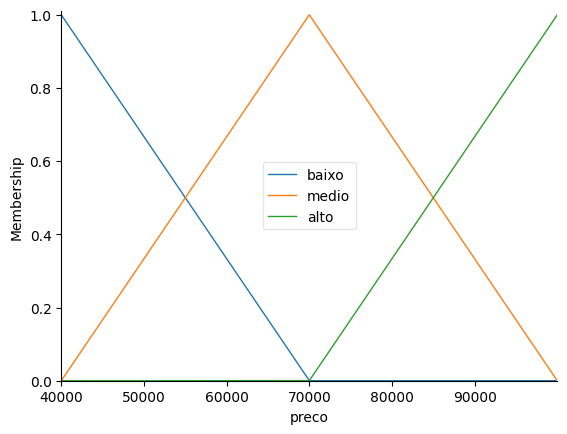

In [ ]:
# Gerar gráficos
preco.view()

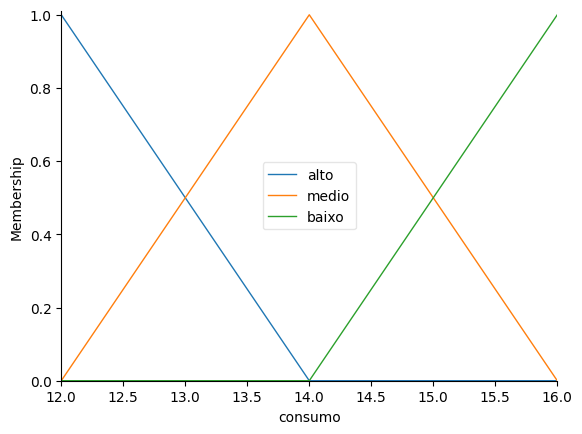

In [ ]:
consumo.view()

**Passo 5:** Definir as classificações para o benefício (universo de valores possíveis para benefício)

In [ ]:
beneficio['baixo'] = fuzz.trimf(beneficio.universe,[0,2.5,5])
beneficio['medio'] = fuzz.trimf(beneficio.universe,[2.5,5,7.5])
beneficio['alto'] = fuzz.trimf(beneficio.universe,[5,7.5,10])

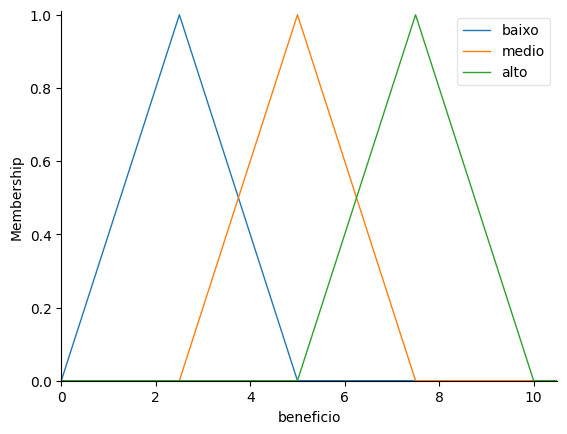

In [ ]:
beneficio.view()

**Passo 6:** Definição das regras

Neste ponto, os resultados da combinação das variáveis linguísticas (preço e consumo) são determinados pelo especialista

In [ ]:
regra1 = ctrl.Rule(preco['baixo'] | consumo['baixo'], beneficio['alto'])
regra2 = ctrl.Rule(preco['baixo'] | consumo['medio'], beneficio['medio'])
regra3 = ctrl.Rule(preco['medio'] | consumo['baixo'], beneficio['medio'])
regra4 = ctrl.Rule(preco['medio'] | consumo['medio'], beneficio['medio'])
regra5 = ctrl.Rule(preco['medio'] | consumo['alto'], beneficio['medio'])
regra6 = ctrl.Rule(preco['alto'] | consumo['medio'], beneficio['medio'])
regra7 = ctrl.Rule(preco['alto'] | consumo['alto'], beneficio['baixo'])
regra8 = ctrl.Rule(preco['baixo'] | consumo['alto'], beneficio['medio'])
regra9 = ctrl.Rule(preco['alto'] | consumo['baixo'], beneficio['medio'])


Passo 7: Aplicação das regras no sistema fuzzy

In [ ]:
recomendacao_compra = ctrl.ControlSystem([regra1,regra2,regra3,regra4,regra5,regra6,regra7,regra8,regra9])

In [ ]:
recomendacao = ctrl.ControlSystemSimulation(recomendacao_compra)

In [ ]:
recomendacao.input['preco'] = 57000


In [ ]:
recomendacao.input['consumo'] = 13
recomendacao.compute()

4.903142710997087


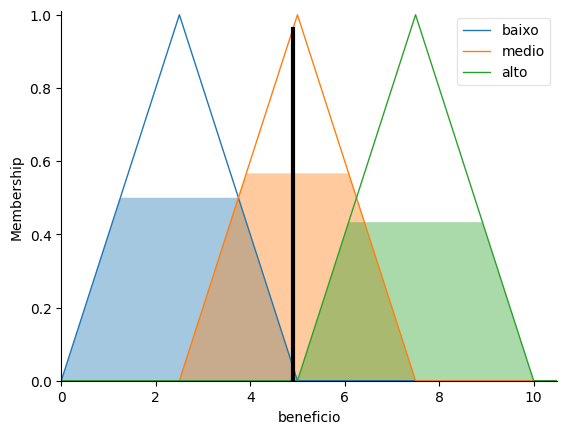

In [ ]:
print(recomendacao.output['beneficio'])
beneficio.view(sim = recomendacao)

O resultado aponta o valor do benefício encontrado pela lógica fuzzy para os valores indicados.